In [1]:
!pip install scikit-image
!pip install opencv-python
!pip install matplotlib

^C
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ------------ --------------------------- 3.7/11.9 MB 21.4 MB/s eta 0:00:01
   ------------------------------------ --- 10.7/11.9 MB 27.4 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 25.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 25.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --------- ------------------------------ 8.4/36.5 MB 40.8 MB/s eta 0:00:01
   -------------------- ------------------- 19.1/36.5 MB 46.8 MB/s eta 0:00:01
   ---------------------------------- ----- 31.7/36.5 MB 51.0 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 50.0 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 41.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ------ --------------------------------- 6.6/40.2 MB 36.7 MB/s eta 0:00:01
   ---------------- ----------------------- 17.0/40.2 MB 43.5 MB/s eta 0:00:01
   --------------------------- ------------ 27.8/40.2 MB 46.9 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 51.0 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 51.0 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 36.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------- ----- 7.1/8.1 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 31.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 31.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import structural_similarity as ssim
import math

In [48]:
def read_image(imagem):
    image = cv2.imread(imagem)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image_rgb

def show_image(imagem):
    plt.imshow(imagem)
    plt.axis('off')
    plt.show

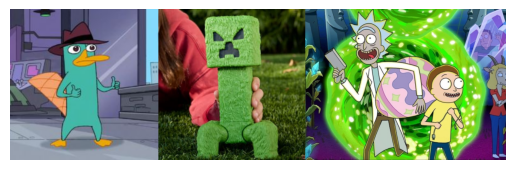

In [ ]:
foto_grupo = read_image('static/foto-grupo.jpeg')
avatares = read_image('static/avatares.png')

show_image(foto_grupo)
show_image(avatares)

In [50]:
DELAY_CAPTION = 1500
DELAY_BLUR = 100
MAX_KERNEL_LENGTH = 31
 
src = None
dst = None
window_name = 'Smoothing Demo'
kernels = [3, 5, 11, 29]


def display_dst(delay):
    cv2.imshow(window_name, dst)
    c = cv2.waitKey(delay)
    if c >= 0 : return -1
    return 0

def display_caption(caption):
    global dst
    dst = np.zeros(src.shape, src.dtype)
    rows, cols, _ch = src.shape
    cv2.putText(dst, caption,
                (int(cols / 4), int(rows / 2)),
                cv2.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255))
    
    return display_dst(DELAY_CAPTION)

def mediana(imagem):
    global src
    src = imagem
    
    if display_caption('Median Blur') != 0:
        return 0

    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.medianBlur(src,k)
        nome_arquivo = f'static/borramento_mediano{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0
    return imagem_ruido


def gaussian(imagem):
    global src
    src = imagem

    # Aplicando o borramento gausiiano
    if display_caption('Gaussian Blur') != 0:
        return 0

    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.GaussianBlur(src, (k,k), 0)  # tupla (k,k) e sigmaX=0
        nome_arquivo = f'static/borramento_gaussiano{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return imagem_ruido


def bilateral(imagem):
    global src
    src = imagem

    # aplicando filtro bilateral
    if display_caption('Bilateral Blur') != 0:
        return 0
 
    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.bilateralFilter(src, k, k*2, k/2)  
        nome_arquivo = f'static/borramento_bilateral{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return imagem_ruido

def media(imagem):
    global src
    src = imagem

    # aplicando filtro de media
    if display_caption('Homogeneous Blur') != 0:
        return 0
 
    resultados = {}

    for k in kernels:
        imagem_ruido = cv2.blur(src, (k,k))
        nome_arquivo = f'static/borramento_media{k}x{k}.jpg'
        imagem_ruido = cv2.cvtColor(imagem_ruido, cv2.COLOR_BGR2RGB)
        cv2.imwrite(nome_arquivo, imagem_ruido)
        resultados[k] = imagem_ruido
        print("imagem salva com sucesso")

        if display_dst(DELAY_BLUR) != 0:
            return 0

    return imagem_ruido

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


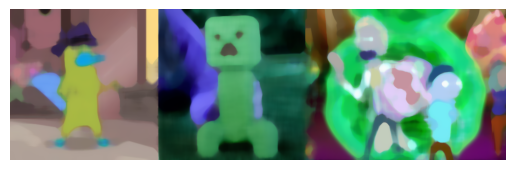

In [51]:
mediana = mediana(avatares)
show_image(mediana)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


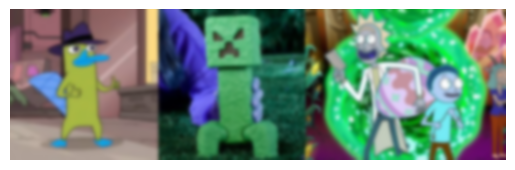

In [52]:
gaussiano = gaussian(avatares)
show_image(gaussiano)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


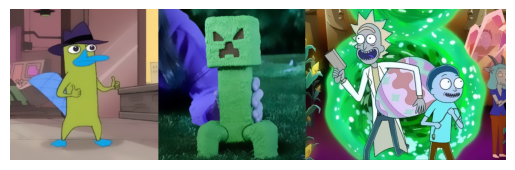

In [53]:
bilateral = bilateral(avatares)
show_image(bilateral)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


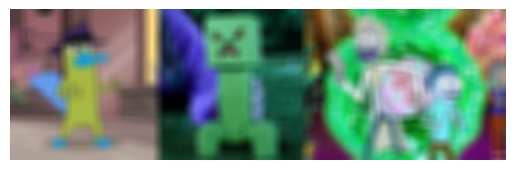

In [54]:
media = media(avatares)
show_image(media)

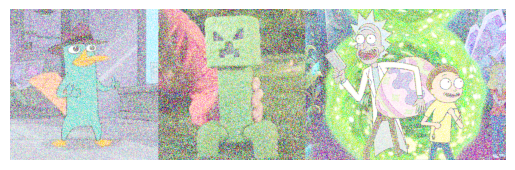

In [55]:
def add_gaussian_noise(imagem, mean=0, std=25):
    noise = np.random.normal(mean,std,imagem.shape).astype(np.uint8)
    noisy_image = cv2.add(imagem, noise)
    return noisy_image

img_ruido = add_gaussian_noise(avatares)
show_image(img_ruido)

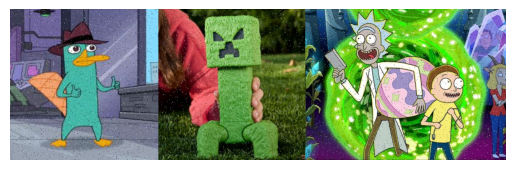

In [56]:
def add_salt_and_pepper_noise(image, noise_ratio=0.02):
    noisy_image = image.copy()
    h, w, c = noisy_image.shape
    noisy_pixels = int(h * w * noise_ratio)
 
    for _ in range(noisy_pixels):
        row, col = np.random.randint(0, h), np.random.randint(0, w)
        if np.random.rand() < 0.5:
            noisy_image[row, col] = [0, 0, 0] 
        else:
            noisy_image[row, col] = [255, 255, 255]
 
    return noisy_image

img_sal_pimenta = add_salt_and_pepper_noise(avatares)
show_image(img_sal_pimenta)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


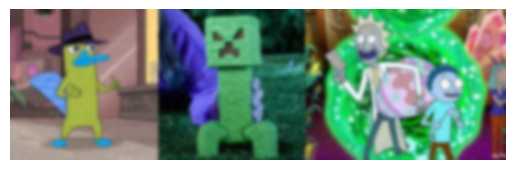

In [57]:
gaussiano_recuperacao = gaussian(img_sal_pimenta)
show_image(gaussiano_recuperacao)

imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso
imagem salva com sucesso


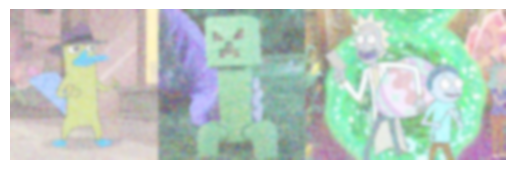

In [58]:
gaussiano = gaussian(img_ruido)
show_image(gaussiano)

In [ ]:
def calcular_psnr(I1, I2):
    s1 = cv2.absdiff(I1, I2)
    s1 = np.float32(s1)
    s1 = s1 * s1
    sse = s1.sum()
    
    # return zero if the difference is extremely small
    if sse <= 1e-10:
        return 0
    else:
        shape = I1.shape
        mse = 1.0 * sse / (shape[0] * shape[1] * shape[2])
        psnr = 10.0 * np.log10((255 * 255) / mse)
        return psnr


def calcular_ssim(I1, I2):
    C1 = 6.5025
    C2 = 58.5225

    # converting to float for squaring
    I1 = np.float32(I1)
    I2 = np.float32(I2)
    I2_2 = I2 * I2
    I1_2 = I1 * I1
    I1_I2 = I1 * I2

    # applying GaussianBlur with (11,11) kernel where mean=st_dev=1.5
    mu1 = cv2.GaussianBlur(I1, (11, 11), 1.5)
    mu2 = cv2.GaussianBlur(I2, (11, 11), 1.5)
    mu1_2 = mu1 * mu1
    mu2_2 = mu2 * mu2
    mu1_mu2 = mu1 * mu2

    sigma1_2 = cv2.GaussianBlur(I1_2, (11, 11), 1.5)
    sigma1_2 -= mu1_2
    sigma2_2 = cv2.GaussianBlur(I2_2, (11, 11), 1.5)
    sigma2_2 -= mu2_2
    sigma12 = cv2.GaussianBlur(I1_I2, (11, 11), 1.5)
    sigma12 -= mu1_mu2

    t1 = 2 * mu1_mu2 + C1
    t2 = 2 * sigma12 + C2
    t3 = t1 * t2  
    t1 = mu1_2 + mu2_2 + C1
    t2 = sigma1_2 + sigma2_2 + C2
    t1 = t1 * t2
    ssim_map = cv2.divide(t3, t1)
    ssim = cv2.mean(ssim_map)[0]  # Corrigido: pega só o valor médio (float)
    return ssim

def avaliar_qualidade(imagem_original, imagem_ruidosa):
    psnr_valor = calcular_psnr(imagem_original, imagem_ruidosa)
    ssim_valor = calcular_ssim(imagem_original, imagem_ruidosa)
    return psnr_valor, ssim_valor

def categoriza_qualidade_psnr(valor):
    if valor is None:
        return 'indefinido'

    if valor >= 35:
        return 'qualidade alta'

    elif valor >= 25:
        return 'qualidade média'

    else:
        return 'qualidade baixa'

def categoriza_qualidade_ssim(valor):
    if valor is None:
        return 'indefinido'

    if valor >= 0.95:
        return 'qualidade alta'

    elif valor >= 0.80:
        return 'qualidade média'

    else:
        return 'qualidade baixa'

Tabela de Qualidade (SSIM):


,bilateral,gaussiano,media,mediano
3,0.984055279107961 (qualidade alta),0.298198107053109 (qualidade baixa),0.906513454053225 (qualidade média),0.934609193501115 (qualidade média)
5,0.981368869714264 (qualidade alta),0.346881233826980 (qualidade baixa),0.783006835487840 (qualidade baixa),0.840209066771215 (qualidade média)
11,0.962582174783025 (qualidade alta),0.418742733036765 (qualidade baixa),0.578968880204191 (qualidade baixa),0.675383680633200 (qualidade baixa)
29,0.880629422849153 (qualidade média),0.401621050486760 (qualidade baixa),0.456436266799818 (qualidade baixa),0.516985426016004 (qualidade baixa)


Gráfico de Qualidade (SSIM):


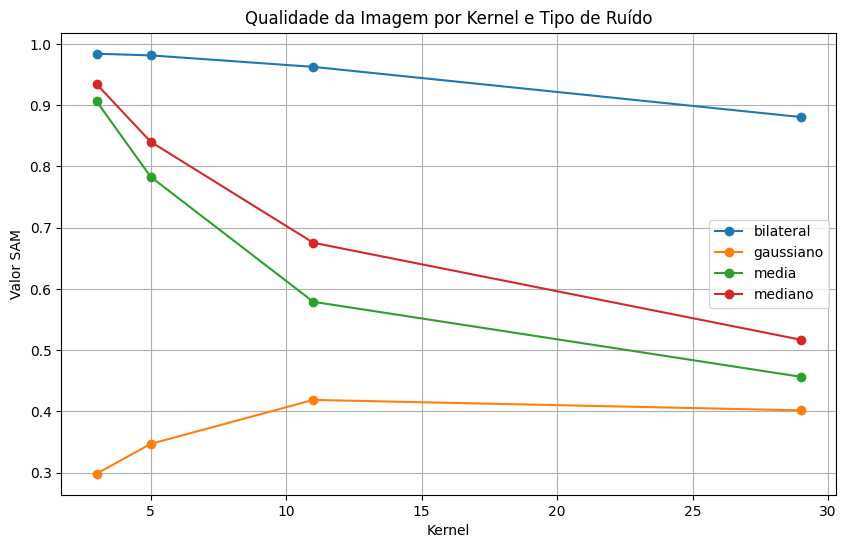

In [ ]:
tipos_ruido = ['bilateral', 'gaussiano', 'media', 'mediano']

# Montando a tabela de resultados
resultados_ssim = {}
resultados_psnr = {}
for kernel in kernels:
    linha_ssim = []
    linha_psnr = []
    for ruido in tipos_ruido:
        try:
            path_img = f'static/borramento_{ruido}{kernel}x{kernel}.jpg'
            imagem_ruidosa = read_image(path_img)
            psnr_valor, ssim_valor = avaliar_qualidade(avatares, imagem_ruidosa)
        except Exception as e:
            psnr_valor = None
            ssim_valor = None
        linha_ssim.append(ssim_valor)
        linha_psnr.append(psnr_valor)
    resultados_ssim[kernel] = linha_ssim
    resultados_psnr[kernel] = linha_psnr


# DataFrame com valores numéricos para gráfico (com 15 casas decimais)
df_valores_ssim = pd.DataFrame(resultados_ssim, index=tipos_ruido).T
df_valores_psnr = pd.DataFrame(resultados_psnr, index=tipos_ruido).T

# DataFrame com qualidade categorizada
df_qualidade_ssim = df_valores_ssim.copy().astype(object)
df_qualidade_psnr = df_valores_psnr.copy().astype(object)

for kernel in kernels:
    for ruido in df_qualidade_ssim.columns:
        valor_ssim = df_qualidade_ssim.loc[kernel, ruido]
        categoria_ssim = categoriza_qualidade_ssim(valor_ssim)

        valor_psnr = df_qualidade_psnr.loc[kernel, ruido]
        categoria_psnr = categoriza_qualidade_psnr(valor_psnr)
        
        if valor_ssim is not None:
            df_qualidade_ssim.loc[kernel, ruido] = f'{valor_ssim:.15f} ({categoria_ssim})'
        else:
            df_qualidade_ssim.loc[kernel, ruido] = 'indefinido'

        if valor_psnr is not None:
            df_qualidade_psnr.loc[kernel, ruido] = f'{valor_psnr:.15f} ({categoria_psnr})'
        else:
            df_qualidade_psnr.loc[kernel, ruido] = 'indefinido'


# Exibindo tabela com qualidade
print("Tabela de Qualidade (SSIM):")
display(df_qualidade_ssim)

print("Gráfico de Qualidade (SSIM):")
# Plotando gráfico com escala ajustada
plt.figure(figsize=(10,6))
for ruido in df_valores_ssim.columns:
    plt.plot(df_valores_ssim.index, df_valores_ssim[ruido], marker='o', label=ruido)
plt.xlabel('Kernel')
plt.ylabel('Valor SSIM')
plt.title('Qualidade da Imagem por Kernel e Tipo de Ruído')
plt.legend()
plt.grid(True)
plt.show()

Tabela de Qualidade (PSNR):


,bilateral,gaussiano,media,mediano
3,40.136711120605469 (qualidade alta),9.145850181579590 (qualidade baixa),27.093095779418945 (qualidade média),28.695091247558594 (qualidade média)
5,39.718395233154297 (qualidade alta),9.212272644042969 (qualidade baixa),23.919303894042969 (qualidade baixa),24.475971221923828 (qualidade baixa)
11,37.132564544677734 (qualidade alta),9.229989051818848 (qualidade baixa),20.878980636596680 (qualidade baixa),21.644996643066406 (qualidade baixa)
29,30.027114868164062 (qualidade média),9.107572555541992 (qualidade baixa),17.602718353271484 (qualidade baixa),18.113449096679688 (qualidade baixa)


Gráfico de Qualidade (PSNR):


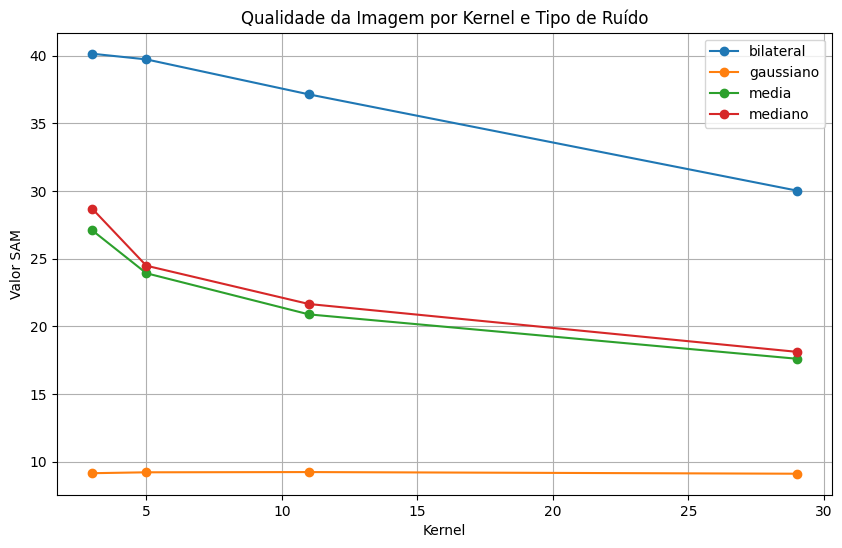

In [ ]:
print("Tabela de Qualidade (PSNR):")
display(df_qualidade_psnr)

print("Gráfico de Qualidade (PSNR):")
# Plotando gráfico com escala ajustada
plt.figure(figsize=(10,6))
for ruido in df_valores_psnr.columns:
    plt.plot(df_valores_psnr.index, df_valores_psnr[ruido], marker='o', label=ruido)
plt.xlabel('Kernel')
plt.ylabel('Valor PSNR')
plt.title('Qualidade da Imagem por Kernel e Tipo de Ruído')
plt.legend()
plt.grid(True)
plt.show()

# Parte 2

In [ ]:
import numpy as np
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()

while True:

    ret, frame = cap.read()

    if not ret:
        print("Can't receive frame")
        break

    # pior resultado: gaussiano 
    filtro_gaussiano = cv2.GaussianBlur(frame, (29,29), 0)

    # melhor resultado: bilateral 
    filtro_bilateral = cv2.bilateralFilter(frame, 3, 6, 1.5)

    cv2.imshow("Original", frame)
    cv2.imshow("Gaussian (pior)", filtro_gaussiano)
    cv2.imshow("Bilateral (melhor)", filtro_bilateral)

    key = cv2.waitKey(1)

    if key == ord('q'):
        break

    if key == ord('s'):
        cv2.imwrite("static/webcam/gaussiano_3x3.jpg", filtro_gaussiano)
        cv2.imwrite("static/webcam/bilateral_3x3.jpg", filtro_bilateral)
        print("Imagens salvas")

cap.release()
cv2.destroyAllWindows()

Imagens salvas
Imagens salvas


KeyboardInterrupt: 

: 